# Compile Resting-State EEG Dataset

This notebook builds a **session-level modeling table** from the BIDS dataset (OpenNeuro ds008768).

Each row corresponds to one resting-state EEG recording and includes:
- Participant demographics and diagnosis group (`PD` vs `Control`)
- Session-level clinical covariates (MoCA, UPDRS-III, disease duration, LEDD, etc.)
- Paths to BrainVision EEG files and basic acquisition metadata

Outputs are saved to the `compiled/` directory as CSV and Parquet.

In [1]:
from __future__ import annotations

import json
import sys
import subprocess
from pathlib import Path

import pandas as pd

# Parquet export requires pyarrow in the active Jupyter kernel environment.
try:
    import pyarrow  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyarrow", "-q"])

# Dataset root is the directory containing this notebook.
DATASET_ROOT = Path(".").resolve()
OUTPUT_DIR = DATASET_ROOT / "compiled"
OUTPUT_DIR.mkdir(exist_ok=True)

NA_VALUES = ["n/a", "N/A", ""]
GROUP_TO_LABEL = {"Control": 0, "PD": 1}

print(f"Dataset root: {DATASET_ROOT}")
print(f"Output dir:   {OUTPUT_DIR}")

Dataset root: C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768
Output dir:   C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768\compiled


In [2]:
def read_bids_tsv(path: Path) -> pd.DataFrame:
    """Read a BIDS TSV file, treating BIDS missing values as NaN."""
    return pd.read_csv(path, sep="\t", na_values=NA_VALUES)


def load_eeg_sidecar(participant_id: str, session_id: str) -> dict:
    """Load BIDS EEG sidecar JSON for a resting-state recording."""
    sidecar_path = (
        DATASET_ROOT
        / participant_id
        / session_id
        / "eeg"
        / f"{participant_id}_{session_id}_task-rest_eeg.json"
    )
    if not sidecar_path.exists():
        return {}

    with sidecar_path.open(encoding="utf-8") as f:
        return json.load(f)


def get_eeg_paths(participant_id: str, session_id: str) -> dict[str, str | None]:
    """Return relative paths to BrainVision files for one session."""
    eeg_dir = DATASET_ROOT / participant_id / session_id / "eeg"
    prefix = f"{participant_id}_{session_id}_task-rest_eeg"

    paths: dict[str, str | None] = {
        "eeg_vhdr": None,
        "eeg_eeg": None,
        "eeg_vmrk": None,
    }

    for suffix, key in [(".vhdr", "eeg_vhdr"), (".eeg", "eeg_eeg"), (".vmrk", "eeg_vmrk")]:
        file_path = eeg_dir / f"{prefix}{suffix}"
        if file_path.exists():
            paths[key] = str(file_path.relative_to(DATASET_ROOT).as_posix())

    return paths


def compile_session_index(root: Path) -> pd.DataFrame:
    """Build one row per resting-state EEG session with labels and covariates."""
    participants = read_bids_tsv(root / "participants.tsv")
    participants = participants.rename(columns={"age": "age_at_first_session"})

    rows: list[dict] = []

    for participant_id in sorted(p.name for p in root.glob("sub-*") if p.is_dir()):
        sessions_path = root / participant_id / f"{participant_id}_sessions.tsv"
        if not sessions_path.exists():
            continue

        sessions = read_bids_tsv(sessions_path)

        for _, session in sessions.iterrows():
            session_id = session["session_id"]
            eeg_paths = get_eeg_paths(participant_id, session_id)
            eeg_meta = load_eeg_sidecar(participant_id, session_id)

            row = {
                "participant_id": participant_id,
                "session_id": session_id,
                **eeg_paths,
                "sampling_frequency_hz": eeg_meta.get("SamplingFrequency"),
                "eeg_reference": eeg_meta.get("EEGReference"),
                "eeg_channel_count": eeg_meta.get("EEGChannelCount"),
                "recording_type": eeg_meta.get("RecordingType"),
                "age_at_visit": session.get("age_at_visit"),
                "moca": session.get("moca"),
                "updrs_part_iii": session.get("updrs_part_iii"),
                "disease_duration_years": session.get("disease_duration"),
                "levodopa_equivalent_daily_dose_mg": session.get(
                    "levodopa_equivalent_daily_dose"
                ),
                "state": session.get("state"),
                "acq_date": session.get("acq_date"),
                "days_since_first_session": session.get("days_since_first_session"),
            }
            rows.append(row)

    sessions_df = pd.DataFrame(rows)
    compiled = sessions_df.merge(participants, on="participant_id", how="left")

    compiled["group_label"] = compiled["group"].map(GROUP_TO_LABEL)

    numeric_cols = [
        "age_at_first_session",
        "education",
        "age_at_visit",
        "moca",
        "updrs_part_iii",
        "disease_duration_years",
        "levodopa_equivalent_daily_dose_mg",
        "days_since_first_session",
        "sampling_frequency_hz",
        "eeg_channel_count",
    ]
    for col in numeric_cols:
        if col in compiled.columns:
            compiled[col] = pd.to_numeric(compiled[col], errors="coerce")

    if "acq_date" in compiled.columns:
        compiled["acq_date"] = pd.to_datetime(compiled["acq_date"], errors="coerce")

    column_order = [
        "participant_id",
        "session_id",
        "group",
        "group_label",
        "sex",
        "race",
        "age_at_first_session",
        "education",
        "age_at_visit",
        "moca",
        "updrs_part_iii",
        "disease_duration_years",
        "levodopa_equivalent_daily_dose_mg",
        "state",
        "acq_date",
        "days_since_first_session",
        "eeg_vhdr",
        "eeg_eeg",
        "eeg_vmrk",
        "sampling_frequency_hz",
        "eeg_reference",
        "eeg_channel_count",
        "recording_type",
    ]
    existing_cols = [c for c in column_order if c in compiled.columns]
    remaining_cols = [c for c in compiled.columns if c not in existing_cols]
    compiled = compiled[existing_cols + remaining_cols]

    return compiled.sort_values(["participant_id", "session_id"]).reset_index(drop=True)

In [3]:
session_index = compile_session_index(DATASET_ROOT)

print(f"Sessions compiled: {len(session_index)}")
print(f"Unique participants: {session_index['participant_id'].nunique()}")
print()
print("Group counts (session-level):")
print(session_index["group"].value_counts(dropna=False))
print()
print("Missing EEG file paths:")
for col in ["eeg_vhdr", "eeg_eeg", "eeg_vmrk"]:
    missing = session_index[col].isna().sum()
    print(f"  {col}: {missing}")

session_index.head(10)

Sessions compiled: 358
Unique participants: 312

Group counts (session-level):
group
PD         240
Control    118
Name: count, dtype: int64

Missing EEG file paths:
  eeg_vhdr: 0
  eeg_eeg: 0
  eeg_vmrk: 0


,participant_id,session_id,group,group_label,sex,race,age_at_first_session,education,age_at_visit,moca,...,state,acq_date,days_since_first_session,eeg_vhdr,eeg_eeg,eeg_vmrk,sampling_frequency_hz,eeg_reference,eeg_channel_count,recording_type
0,sub-1,ses-01,Control,0,F,White,67.1,16.0,67.1,28.0,...,EO,2016-06-30,0,sub-1/ses-01/eeg/sub-1_ses-01_task-rest_eeg.vhdr,sub-1/ses-01/eeg/sub-1_ses-01_task-rest_eeg.eeg,sub-1/ses-01/eeg/sub-1_ses-01_task-rest_eeg.vmrk,500,Pz,63,continuous
1,sub-1,ses-02,Control,0,F,White,67.1,16.0,69.0,NaN,...,EO,2019-01-19,933,sub-1/ses-02/eeg/sub-1_ses-02_task-rest_eeg.vhdr,sub-1/ses-02/eeg/sub-1_ses-02_task-rest_eeg.eeg,sub-1/ses-02/eeg/sub-1_ses-02_task-rest_eeg.vmrk,500,Pz,63,continuous
2,sub-10,ses-01,Control,0,M,White,74.5,17.0,74.5,26.0,...,EO,2013-04-11,0,sub-10/ses-01/eeg/sub-10_ses-01_task-rest_eeg....,sub-10/ses-01/eeg/sub-10_ses-01_task-rest_eeg.eeg,sub-10/ses-01/eeg/sub-10_ses-01_task-rest_eeg....,500,Pz,63,continuous
3,sub-100,ses-01,Control,0,M,White,76.0,16.0,76.0,28.0,...,EO,2017-06-03,0,sub-100/ses-01/eeg/sub-100_ses-01_task-rest_ee...,sub-100/ses-01/eeg/sub-100_ses-01_task-rest_ee...,sub-100/ses-01/eeg/sub-100_ses-01_task-rest_ee...,500,Pz,63,continuous
4,sub-100,ses-02,Control,0,M,White,76.0,16.0,80.3,26.0,...,EO,2021-01-25,1332,sub-100/ses-02/eeg/sub-100_ses-02_task-rest_ee...,sub-100/ses-02/eeg/sub-100_ses-02_task-rest_ee...,sub-100/ses-02/eeg/sub-100_ses-02_task-rest_ee...,500,Pz,63,continuous
5,sub-101,ses-01,Control,0,F,NaN,71.0,16.0,71.0,28.0,...,EO,2012-03-25,0,sub-101/ses-01/eeg/sub-101_ses-01_task-rest_ee...,sub-101/ses-01/eeg/sub-101_ses-01_task-rest_ee...,sub-101/ses-01/eeg/sub-101_ses-01_task-rest_ee...,500,Pz,63,continuous
6,sub-102,ses-01,Control,0,F,NaN,86.0,12.0,86.0,27.0,...,EO,2016-07-17,0,sub-102/ses-01/eeg/sub-102_ses-01_task-rest_ee...,sub-102/ses-01/eeg/sub-102_ses-01_task-rest_ee...,sub-102/ses-01/eeg/sub-102_ses-01_task-rest_ee...,500,Pz,63,continuous
7,sub-103,ses-01,Control,0,M,NaN,75.0,20.0,75.0,28.0,...,EO,2007-06-10,0,sub-103/ses-01/eeg/sub-103_ses-01_task-rest_ee...,sub-103/ses-01/eeg/sub-103_ses-01_task-rest_ee...,sub-103/ses-01/eeg/sub-103_ses-01_task-rest_ee...,500,Pz,63,continuous
8,sub-104,ses-01,Control,0,F,NaN,69.0,17.0,69.0,22.0,...,EO,2019-10-06,0,sub-104/ses-01/eeg/sub-104_ses-01_task-rest_ee...,sub-104/ses-01/eeg/sub-104_ses-01_task-rest_ee...,sub-104/ses-01/eeg/sub-104_ses-01_task-rest_ee...,500,Pz,63,continuous
9,sub-105,ses-01,Control,0,F,NaN,74.0,14.0,74.0,27.0,...,EO,2006-02-07,0,sub-105/ses-01/eeg/sub-105_ses-01_task-rest_ee...,sub-105/ses-01/eeg/sub-105_ses-01_task-rest_ee...,sub-105/ses-01/eeg/sub-105_ses-01_task-rest_ee...,500,Pz,63,continuous


In [4]:
clinical_cols = [
    "moca",
    "updrs_part_iii",
    "disease_duration_years",
    "levodopa_equivalent_daily_dose_mg",
]

coverage = (
    session_index.groupby("group")[clinical_cols]
    .apply(lambda df: df.notna().sum())
    .astype(int)
)
coverage.columns = [f"{c}_non_null" for c in clinical_cols]
coverage

,moca_non_null,updrs_part_iii_non_null,disease_duration_years_non_null,levodopa_equivalent_daily_dose_mg_non_null
group,,,,
Control,88,0,0,0
PD,132,132,132,131


In [5]:
def save_table(df: pd.DataFrame, stem: str) -> None:
    """Save a table as CSV and Parquet when pyarrow is available."""
    csv_path = OUTPUT_DIR / f"{stem}.csv"
    parquet_path = OUTPUT_DIR / f"{stem}.parquet"

    df.to_csv(csv_path, index=False)
    print(f"Saved CSV: {csv_path}")

    try:
        df.to_parquet(parquet_path, index=False)
        print(f"Saved Parquet: {parquet_path}")
    except Exception as exc:
        print(f"Skipped Parquet export ({type(exc).__name__}): {exc}")


participant_index = (
    session_index.sort_values(["participant_id", "session_id"])
    .groupby("participant_id", as_index=False)
    .first()
)

save_table(session_index, "session_index")
save_table(participant_index, "participant_index")

Saved CSV: C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768\compiled\session_index.csv
Saved Parquet: C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768\compiled\session_index.parquet
Saved CSV: C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768\compiled\participant_index.csv
Saved Parquet: C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768\compiled\participant_index.parquet


## Modeling prep, EEG loading, and descriptive analysis

The sections below:
1. Load `session_index.parquet` as the master modeling table
2. Parse EEG metadata from **BIDS sidecars and `.vhdr` headers** (fast — no MNE, no waveform download)
3. Extract **EEG voltage summary stats** from local `.eeg` files (no bulk download)
4. **One-hot encode** string categoricals
5. Build a unified descriptive statistics table (count, range, measurement level, skew, IQR outliers)
6. Visualize demographics, clinical covariates, EEG metadata, and voltage summaries

We use **local `.eeg` files only** — no additional downloads.


In [6]:
# Step 1: load the compiled master table
session_index = pd.read_parquet(OUTPUT_DIR / "session_index.parquet")
participant_index = pd.read_parquet(OUTPUT_DIR / "participant_index.parquet")

print(f"Sessions: {len(session_index)} | Participants: {participant_index['participant_id'].nunique()}")
session_index.head(3)

Sessions: 358 | Participants: 312


,participant_id,session_id,group,group_label,sex,race,age_at_first_session,education,age_at_visit,moca,...,state,acq_date,days_since_first_session,eeg_vhdr,eeg_eeg,eeg_vmrk,sampling_frequency_hz,eeg_reference,eeg_channel_count,recording_type
0,sub-1,ses-01,Control,0,F,White,67.1,16.0,67.1,28.0,...,EO,2016-06-30,0,sub-1/ses-01/eeg/sub-1_ses-01_task-rest_eeg.vhdr,sub-1/ses-01/eeg/sub-1_ses-01_task-rest_eeg.eeg,sub-1/ses-01/eeg/sub-1_ses-01_task-rest_eeg.vmrk,500,Pz,63,continuous
1,sub-1,ses-02,Control,0,F,White,67.1,16.0,69.0,NaN,...,EO,2019-01-19,933,sub-1/ses-02/eeg/sub-1_ses-02_task-rest_eeg.vhdr,sub-1/ses-02/eeg/sub-1_ses-02_task-rest_eeg.eeg,sub-1/ses-02/eeg/sub-1_ses-02_task-rest_eeg.vmrk,500,Pz,63,continuous
2,sub-10,ses-01,Control,0,M,White,74.5,17.0,74.5,26.0,...,EO,2013-04-11,0,sub-10/ses-01/eeg/sub-10_ses-01_task-rest_eeg....,sub-10/ses-01/eeg/sub-10_ses-01_task-rest_eeg.eeg,sub-10/ses-01/eeg/sub-10_ses-01_task-rest_eeg....,500,Pz,63,continuous


### Fast EEG metadata (BIDS + `.vhdr` parsing)

For descriptive analysis we **do not** load waveforms with MNE. Instead we:
- Reuse BIDS JSON fields already in `session_index` (`sampling_frequency_hz`, `eeg_channel_count`, …)
- Parse the tiny BrainVision `.vhdr` header (works even when `.eeg` is still a git-annex pointer)
- Estimate `recording_duration_sec` only when the local `.eeg` file is present

Results are cached to `compiled/eeg_metadata.parquet` so re-runs are instant.

To download full EEG recordings (~10–15 GB) for waveform modeling, use the **optional** git-annex cell near the bottom.

In [7]:
EEG_META_CACHE = OUTPUT_DIR / "eeg_metadata.parquet"


def is_git_annex_pointer(path: Path) -> bool:
    if not path.exists():
        return True
    with path.open("rb") as f:
        head = f.read(256)
    return b"/annex/" in head or head.startswith(b"../../.git/annex")


def resolve_git_annex_pointer(path: Path) -> Path:
    """Return a readable BrainVision header (.vhdr) path."""
    if not path.exists() or not is_git_annex_pointer(path):
        return path
    pointer = path.read_text(encoding="utf-8", errors="replace").strip()
    if ".git/annex" in pointer or pointer.startswith(".."):
        resolved = (path.parent / pointer).resolve()
        if resolved.exists():
            return resolved
    return path


def parse_brainvision_vhdr(vhdr_rel_path: str) -> dict:
    """Parse BrainVision header metadata without MNE or downloading .eeg data."""
    vhdr_path = resolve_git_annex_pointer(DATASET_ROOT / vhdr_rel_path)
    if not vhdr_path.exists():
        raise FileNotFoundError(
            f"Header not found at {vhdr_path}. Clone the dataset and ensure .vhdr paths exist."
        )

    meta: dict = {}
    with vhdr_path.open(encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if "=" not in line or line.startswith(";"):
                continue
            key, value = line.split("=", 1)
            if key == "SamplingInterval":
                meta["sampling_interval_us"] = float(value)
            elif key == "NumberOfChannels":
                meta["n_channels_total"] = int(value)
            elif key == "BinaryFormat":
                meta["binary_format"] = value
            elif key == "DataFile":
                meta["data_file"] = value

    if "sampling_interval_us" in meta:
        meta["sampling_frequency_hz_vhdr"] = 1_000_000 / meta["sampling_interval_us"]
        meta["sampling_frequency_hz_mne"] = meta["sampling_frequency_hz_vhdr"]

    meta["n_channels_eeg"] = meta.get("n_channels_total")
    meta["recording_duration_sec"] = pd.NA
    meta["eeg_data_local"] = False

    if "data_file" in meta and "n_channels_total" in meta:
        eeg_path = vhdr_path.parent / meta["data_file"]
        if eeg_path.exists() and not is_git_annex_pointer(eeg_path):
            bytes_per_sample = 4 if meta.get("binary_format") == "IEEE_FLOAT_32" else 2
            n_times = eeg_path.stat().st_size / (meta["n_channels_total"] * bytes_per_sample)
            sfreq = meta.get("sampling_frequency_hz_vhdr")
            if sfreq:
                meta["recording_duration_sec"] = n_times / sfreq
                meta["eeg_data_local"] = True

    return meta


def apply_bids_fallback(meta: dict, row: pd.Series) -> dict:
    """Fill missing EEG fields from BIDS sidecar values already in session_index."""
    if pd.isna(meta.get("sampling_frequency_hz_vhdr")):
        sfreq = row.get("sampling_frequency_hz")
        if pd.notna(sfreq):
            meta["sampling_frequency_hz_vhdr"] = float(sfreq)
            meta["sampling_frequency_hz_mne"] = float(sfreq)
    if pd.isna(meta.get("n_channels_total")):
        n_ch = row.get("eeg_channel_count")
        if pd.notna(n_ch):
            meta["n_channels_total"] = int(n_ch)
            meta["n_channels_eeg"] = int(n_ch)
    return meta


def load_eeg_metadata_fast(session_df: pd.DataFrame, use_cache: bool = True) -> pd.DataFrame:
    if use_cache and EEG_META_CACHE.exists():
        cached = pd.read_parquet(EEG_META_CACHE)
        if len(cached) == len(session_df):
            print(f"Loaded cached EEG metadata: {EEG_META_CACHE}")
            return cached

    rows: list[dict] = []
    for _, row in session_df.iterrows():
        try:
            meta = parse_brainvision_vhdr(row["eeg_vhdr"])
            meta["eeg_load_error"] = pd.NA
        except Exception as exc:
            meta = {
                "eeg_load_error": str(exc),
                "recording_duration_sec": pd.NA,
                "sampling_frequency_hz_vhdr": pd.NA,
                "sampling_frequency_hz_mne": pd.NA,
                "n_channels_total": pd.NA,
                "n_channels_eeg": pd.NA,
                "eeg_data_local": False,
            }
        meta = apply_bids_fallback(meta, row)
        meta["eeg_load_ok"] = pd.notna(meta.get("sampling_frequency_hz_vhdr")) or pd.notna(
            meta.get("n_channels_total")
        )
        rows.append(meta)

    eeg_meta = pd.DataFrame(rows)
    eeg_meta.to_parquet(EEG_META_CACHE, index=False)
    print(f"Cached EEG metadata: {EEG_META_CACHE}")
    return eeg_meta


eeg_meta = load_eeg_metadata_fast(session_index)
modeling_table = pd.concat([session_index.reset_index(drop=True), eeg_meta], axis=1)

loaded = int(modeling_table["eeg_load_ok"].sum())
local_data = int(modeling_table.get("eeg_data_local", pd.Series(False)).fillna(False).sum())
print(f"EEG headers parsed: {loaded} / {len(modeling_table)}")
print(f"Sessions with local .eeg waveform files: {local_data} / {len(modeling_table)}")

if local_data == 0:
    print(
        "\nNote: recording duration is unavailable until .eeg files are downloaded.\n"
        "Descriptive statistics use BIDS + .vhdr metadata and do not require waveforms."
    )
elif modeling_table["recording_duration_sec"].notna().any():
    dur = pd.to_numeric(modeling_table["recording_duration_sec"], errors="coerce").dropna()
    print(
        f"Recording duration (min): median={dur.median() / 60:.1f}, mean={dur.mean() / 60:.1f}"
    )

modeling_table.head(3)

Loaded cached EEG metadata: C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768\compiled\eeg_metadata.parquet
EEG headers parsed: 358 / 358
Sessions with local .eeg waveform files: 266 / 358
Recording duration (min): median=3.0, mean=3.3


,participant_id,session_id,group,group_label,sex,race,age_at_first_session,education,age_at_visit,moca,...,n_channels_total,sampling_interval_us,binary_format,sampling_frequency_hz_vhdr,sampling_frequency_hz_mne,n_channels_eeg,recording_duration_sec,eeg_data_local,eeg_load_error,eeg_load_ok
0,sub-1,ses-01,Control,0,F,White,67.1,16.0,67.1,28.0,...,63,2000.0,IEEE_FLOAT_32,500.0,500.0,63,180.56,True,None,True
1,sub-1,ses-02,Control,0,F,White,67.1,16.0,69.0,NaN,...,64,2000.0,IEEE_FLOAT_32,500.0,500.0,64,304.04,True,None,True
2,sub-10,ses-01,Control,0,M,White,74.5,17.0,74.5,26.0,...,63,2000.0,IEEE_FLOAT_32,500.0,500.0,63,181.08,True,None,True


### EEG voltage summaries (local `.eeg` files only)

Reads BrainVision waveforms **only when the `.eeg` file is already on disk** (no bulk git-annex download).

**Missing data:** Sessions whose `.eeg` file is still a git-annex pointer are skipped (`voltage_error = eeg_not_local`). This affects some participants entirely and others only for specific sessions.

**Why filtered features?** Raw voltage means are dominated by DC offset and the Pz reference — not comparable across recordings. We therefore compute **normalized, filtered** session summaries:

1. **Common-average re-reference (CAR)** — subtract the across-channel mean at each time point
2. **Bandpass 1–40 Hz** — remove DC drift and high-frequency noise
3. **Relative band power** — alpha (8–13 Hz) and beta (13–30 Hz) as a fraction of 1–40 Hz power

Outputs:
- Per-channel stats → `compiled/voltage_by_session/{participant}_{session}_voltage.parquet`
- Session summaries → merged into `modeling_table`, including `eeg_voltage_mean_uv` and `eeg_voltage_skew` (CAR + 1–40 Hz filtered; missing sessions are skipped)


In [8]:
VOLTAGE_SUMMARY_CACHE = OUTPUT_DIR / "eeg_filtered_summaries.parquet"
VOLTAGE_BY_SESSION_DIR = OUTPUT_DIR / "voltage_by_session"
VOLTAGE_BY_SESSION_DIR.mkdir(exist_ok=True)

try:
    from scipy import stats as scipy_stats
    from scipy.signal import butter, sosfiltfilt, welch
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy", "-q"])
    from scipy import stats as scipy_stats
    from scipy.signal import butter, sosfiltfilt, welch

import numpy as np

FILTER_LOW_HZ = 1.0
FILTER_HIGH_HZ = 40.0
TARGET_MAX_SAMPLES = 360_000  # cap length for filtering (~12 min at 500 Hz)


def parse_vhdr_channel_names(vhdr_rel_path: str) -> list[str]:
    """Return channel names from a BrainVision header."""
    vhdr_path = resolve_git_annex_pointer(DATASET_ROOT / vhdr_rel_path)
    names: list[str] = []
    in_channel_section = False
    with vhdr_path.open(encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if line == "[Channel Infos]":
                in_channel_section = True
                continue
            if line.startswith("[") and in_channel_section:
                break
            if in_channel_section and line.startswith("Ch") and "=" in line:
                prefix, rest = line.split("=", 1)
                if prefix[2:].isdigit():
                    names.append(rest.split(",")[0])
    return names


def eeg_channel_indices(vhdr_rel_path: str, n_channels: int) -> np.ndarray:
    """Indices of EEG scalp channels (µV), excluding aux channels like Audio."""
    names = parse_vhdr_channel_names(vhdr_rel_path)
    if len(names) != n_channels:
        return np.arange(n_channels)
    idx = [i for i, name in enumerate(names) if name.lower() != "audio"]
    return np.array(idx, dtype=int)


def sampling_rate_hz(meta: dict, row: pd.Series) -> float:
    if meta.get("sampling_interval_us"):
        return 1_000_000 / float(meta["sampling_interval_us"])
    sfreq = row.get("sampling_frequency_hz")
    if pd.notna(sfreq):
        return float(sfreq)
    return 500.0


def bandpass_filter(data: np.ndarray, sfreq: float) -> np.ndarray:
    nyq = sfreq / 2.0
    high = min(FILTER_HIGH_HZ, nyq * 0.99)
    low = min(FILTER_LOW_HZ, high * 0.5)
    sos = butter(4, [low / nyq, high / nyq], btype="band", output="sos")
    return sosfiltfilt(sos, data, axis=0)


def relative_band_power(data: np.ndarray, sfreq: float, band: tuple[float, float]) -> np.ndarray:
    """Per-channel relative power of `band` within the 1–40 Hz broadband."""
    nperseg = min(2048, data.shape[0])
    rel_powers: list[float] = []
    for ch in range(data.shape[1]):
        freqs, psd = welch(data[:, ch], fs=sfreq, nperseg=nperseg)
        band_mask = (freqs >= band[0]) & (freqs <= band[1])
        bb_mask = (freqs >= FILTER_LOW_HZ) & (freqs <= min(FILTER_HIGH_HZ, sfreq / 2 * 0.99))
        band_power = psd[band_mask].sum()
        total_power = psd[bb_mask].sum()
        rel_powers.append(band_power / max(total_power, 1e-12))
    return np.array(rel_powers, dtype=np.float64)


def compute_voltage_summaries_for_session(row: pd.Series) -> tuple[dict, pd.DataFrame | None]:
    """Compute filtered, normalized voltage stats from a local .eeg file."""
    vhdr_rel = row.get("eeg_vhdr")
    if pd.isna(vhdr_rel):
        return {"voltage_available": False, "voltage_error": "missing_vhdr"}, None

    try:
        meta = parse_brainvision_vhdr(vhdr_rel)
    except Exception as exc:
        return {"voltage_available": False, "voltage_error": str(exc)}, None

    if not meta.get("eeg_data_local"):
        return {"voltage_available": False, "voltage_error": "eeg_not_local"}, None

    vhdr_path = resolve_git_annex_pointer(DATASET_ROOT / vhdr_rel)
    eeg_path = vhdr_path.parent / meta["data_file"]
    n_channels = int(meta["n_channels_total"])
    bytes_per_sample = 4 if meta.get("binary_format") == "IEEE_FLOAT_32" else 2
    dtype = np.float32 if bytes_per_sample == 4 else np.int16

    eeg_idx = eeg_channel_indices(vhdr_rel, n_channels)
    channel_names = parse_vhdr_channel_names(vhdr_rel)
    ch_names = (
        [channel_names[i] for i in eeg_idx]
        if len(channel_names) == n_channels
        else [f"Ch{i + 1}" for i in eeg_idx]
    )
    n_eeg = len(eeg_idx)
    file_samples = eeg_path.stat().st_size // (n_channels * bytes_per_sample)
    sfreq = sampling_rate_hz(meta, row)

    dec = max(1, int(np.ceil(file_samples / TARGET_MAX_SAMPLES)))
    effective_sfreq = sfreq / dec

    memmap_data = np.memmap(
        eeg_path, dtype=dtype, mode="r", shape=(file_samples, n_channels)
    )
    data = np.asarray(memmap_data[::dec, :][:, eeg_idx], dtype=np.float64)
    n_used = data.shape[0]

    # Common-average re-reference (reduces Pz/shared-reference contamination)
    data_car = data - data.mean(axis=1, keepdims=True)
    data_filt = bandpass_filter(data_car, effective_sfreq)

    ch_mean_abs = np.mean(np.abs(data_filt), axis=0)
    ch_rms = np.sqrt(np.mean(np.square(data_filt), axis=0))
    ch_std = data_filt.std(axis=0)
    ch_skew = scipy_stats.skew(data_filt, axis=0, bias=False, nan_policy="omit")
    session_skew = float(scipy_stats.skew(data_filt.reshape(-1), bias=False))
    alpha_rel = relative_band_power(data_filt, effective_sfreq, (8.0, 13.0))
    beta_rel = relative_band_power(data_filt, effective_sfreq, (13.0, 30.0))

    by_channel = pd.DataFrame(
        {
            "participant_id": row["participant_id"],
            "session_id": row["session_id"],
            "channel": ch_names,
            "voltage_mean_uv": ch_mean_abs,
            "voltage_skew": ch_skew,
            "filt_rms_uv": ch_rms,
            "filt_std_uv": ch_std,
            "filt_skew": ch_skew,
            "filt_alpha_rel": alpha_rel,
            "filt_beta_rel": beta_rel,
            "n_samples_used": n_used,
            "effective_sfreq_hz": effective_sfreq,
        }
    )

    session_summary = {
        "voltage_available": True,
        "voltage_error": pd.NA,
        "eeg_voltage_mean_uv": float(np.mean(ch_mean_abs)),
        "eeg_voltage_skew": session_skew,
        "eeg_filt_rms_uv": float(np.mean(ch_rms)),
        "eeg_filt_std_uv": float(np.mean(ch_std)),
        "eeg_filt_skew": session_skew,
        "eeg_filt_alpha_rel": float(np.mean(alpha_rel)),
        "eeg_filt_beta_rel": float(np.mean(beta_rel)),
        "eeg_voltage_n_samples": int(n_used),
        "eeg_voltage_n_channels": int(n_eeg),
        "eeg_filt_effective_sfreq_hz": float(effective_sfreq),
    }
    return session_summary, by_channel


def load_voltage_summaries(session_df: pd.DataFrame, use_cache: bool = True) -> pd.DataFrame:
    if use_cache and VOLTAGE_SUMMARY_CACHE.exists():
        cached = pd.read_parquet(VOLTAGE_SUMMARY_CACHE)
        required = {"eeg_voltage_mean_uv", "eeg_voltage_skew"}
        if len(cached) == len(session_df) and required.issubset(cached.columns):
            print(f"Loaded cached filtered voltage summaries: {VOLTAGE_SUMMARY_CACHE}")
            return cached

    rows: list[dict] = []
    for i, (_, row) in enumerate(session_df.iterrows(), start=1):
        summary, by_channel = compute_voltage_summaries_for_session(row)
        rows.append(summary)
        if by_channel is not None:
            out_path = (
                VOLTAGE_BY_SESSION_DIR
                / f"{row['participant_id']}_{row['session_id']}_voltage.parquet"
            )
            by_channel.to_parquet(out_path, index=False)
        if i % 50 == 0:
            print(f"Processed {i}/{len(session_df)} sessions")

    voltage_meta = pd.DataFrame(rows)
    voltage_meta.to_parquet(VOLTAGE_SUMMARY_CACHE, index=False)
    print(f"Cached filtered voltage summaries: {VOLTAGE_SUMMARY_CACHE}")
    return voltage_meta


voltage_meta = load_voltage_summaries(modeling_table)
modeling_table = pd.concat(
    [modeling_table.reset_index(drop=True), voltage_meta.reset_index(drop=True)],
    axis=1,
)

available = int(modeling_table["voltage_available"].fillna(False).sum())
missing = len(modeling_table) - available
print(f"Sessions with filtered voltage: {available} / {len(modeling_table)}")
print(f"Sessions missing (no local .eeg): {missing}")

if available:
    by_group = pd.crosstab(
        modeling_table["group"],
        modeling_table["voltage_available"].fillna(False),
        margins=True,
    )
    print("\nAvailability by group (columns = has local waveform):")
    print(by_group)

    n_participants_any = modeling_table.loc[
        modeling_table["voltage_available"].fillna(False), "participant_id"
    ].nunique()
    n_participants_none = (
        set(modeling_table["participant_id"])
        - set(modeling_table.loc[modeling_table["voltage_available"].fillna(False), "participant_id"])
    )
    print(
        f"\nParticipants with >=1 voltage session: {n_participants_any} / "
        f"{modeling_table['participant_id'].nunique()}"
    )
    print(f"Participants with no local voltage data: {len(n_participants_none)}")

    vmean = modeling_table.loc[modeling_table["voltage_available"], "eeg_voltage_mean_uv"]
    print(
        f"\nMean voltage (µV, filtered): median={vmean.median():.3f}, "
        f"mean={vmean.mean():.3f}, range=[{vmean.min():.3f}, {vmean.max():.3f}]"
    )
else:
    print("No local .eeg files found. Missing sessions are skipped (no download).")

save_table(modeling_table, "modeling_table")
modeling_table.filter(
    regex="^(participant_id|session_id|group|voltage_|eeg_voltage_|eeg_filt_)"
).head(3)


Processed 50/358 sessions
Processed 100/358 sessions
Processed 150/358 sessions
Processed 200/358 sessions
Processed 250/358 sessions
Processed 300/358 sessions
Processed 350/358 sessions
Cached filtered voltage summaries: C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768\compiled\eeg_filtered_summaries.parquet
Sessions with filtered voltage: 266 / 358
Sessions missing (no local .eeg): 92

Availability by group (columns = has local waveform):
voltage_available  False  True  All
group                              
Control               79    39  118
PD                    13   227  240
All                   92   266  358

Participants with >=1 voltage session: 226 / 312
Participants with no local voltage data: 86

Mean voltage (µV, filtered): median=97.999, mean=133.915, range=[40.431, 3353.682]
Saved CSV: C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768\compiled\modeling_table.csv
Saved Parquet: C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768\co

,participant_id,session_id,group,group_label,voltage_available,voltage_error,eeg_voltage_mean_uv,eeg_voltage_skew,eeg_filt_rms_uv,eeg_filt_std_uv,eeg_filt_skew,eeg_filt_alpha_rel,eeg_filt_beta_rel,eeg_voltage_n_samples,eeg_voltage_n_channels,eeg_filt_effective_sfreq_hz
0,sub-1,ses-01,Control,0,True,NaN,113.332839,0.002190,144.140583,144.140515,0.002190,0.107661,0.432414,90280.0,63.0,500.0
1,sub-1,ses-02,Control,0,True,NaN,85.649257,0.783466,136.706277,136.706273,0.783466,0.068775,0.270495,152020.0,63.0,500.0
2,sub-10,ses-01,Control,0,True,NaN,117.434095,2.379245,179.560449,179.560420,2.379245,0.061158,0.091968,90540.0,63.0,500.0


### One-hot encode categorical features

Convert string fields to numeric dummy columns **before** compiling descriptive statistics.

In [9]:
categorical_to_encode = ["group", "sex", "race", "state"]

numeric_keep = [
    "group_label",
    "age_at_first_session",
    "education",
    "age_at_visit",
    "moca",
    "updrs_part_iii",
    "disease_duration_years",
    "levodopa_equivalent_daily_dose_mg",
    "days_since_first_session",
    "sampling_frequency_hz",
    "eeg_channel_count",
    "recording_duration_sec",
    "sampling_frequency_hz_mne",
    "sampling_frequency_hz_vhdr",
    "n_channels_total",
    "n_channels_eeg",
    "eeg_voltage_mean_uv",
    "eeg_voltage_skew",
    "eeg_filt_rms_uv",
    "eeg_filt_std_uv",
    "eeg_filt_skew",
    "eeg_filt_alpha_rel",
    "eeg_filt_beta_rel",
    "eeg_voltage_n_samples",
    "eeg_voltage_n_channels",
    "eeg_filt_effective_sfreq_hz",
]

id_cols = ["participant_id", "session_id"]
path_cols = [
    c for c in modeling_table.columns
    if c.startswith("eeg_") and c.endswith(("_vhdr", "_eeg", "_vmrk"))
]
meta_cols = ["eeg_reference", "recording_type", "eeg_load_ok", "eeg_data_local", "voltage_available", "voltage_error"]

encode_source = modeling_table.copy()
encode_source["recording_duration_sec"] = pd.to_numeric(
    encode_source["recording_duration_sec"], errors="coerce"
)

dummy_cols = pd.get_dummies(
    encode_source[categorical_to_encode],
    prefix=categorical_to_encode,
    dummy_na=True,
    dtype=int,
)

keep_cols = [c for c in id_cols + numeric_keep + path_cols + meta_cols if c in encode_source.columns]
modeling_table_encoded = pd.concat(
    [encode_source[keep_cols].reset_index(drop=True), dummy_cols.reset_index(drop=True)],
    axis=1,
)

print(f"Encoded shape: {modeling_table_encoded.shape}")
print("One-hot columns:")
print([
    c for c in modeling_table_encoded.columns
    if any(c.startswith(f"{cat}_") for cat in categorical_to_encode)
])

display(modeling_table_encoded.filter(like="group_").head(3))
save_table(modeling_table_encoded, "modeling_table_encoded")


Encoded shape: (358, 48)
One-hot columns:
['group_label', 'group_Control', 'group_PD', 'group_nan', 'sex_F', 'sex_M', 'sex_nan', 'race_Asian', 'race_White', 'race_nan', 'state_EO', 'state_nan']


,group_label,group_Control,group_PD,group_nan
0,0,1,0,0
1,0,1,0,0
2,0,1,0,0


Saved CSV: C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768\compiled\modeling_table_encoded.csv
Saved Parquet: C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768\compiled\modeling_table_encoded.parquet


### Descriptive analysis

Summaries below use **participant-level** data for demographics and **session-level** data for clinical / EEG variables (after one-hot encoding).

In [10]:
demo_cols = ["age_at_first_session", "education"]
clinical_cols = [
    "age_at_visit",
    "moca",
    "updrs_part_iii",
    "disease_duration_years",
    "levodopa_equivalent_daily_dose_mg",
    "days_since_first_session",
]
eeg_cols = [
    "sampling_frequency_hz",
    "eeg_channel_count",
    "recording_duration_sec",
    "eeg_voltage_mean_uv",
    "eeg_voltage_skew",
    "eeg_filt_rms_uv",
    "eeg_filt_std_uv",
    "eeg_filt_skew",
    "eeg_filt_alpha_rel",
    "eeg_filt_beta_rel",
]

analysis_vars = demo_cols + clinical_cols + eeg_cols

# Coerce to float so pd.NA from failed EEG loads doesn't break .agg()
analysis_df = modeling_table[["group"] + analysis_vars].copy()
for col in analysis_vars:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

# --- Missingness ---
missing_session = analysis_df[analysis_vars].isna().mean().mul(100).round(1)
missing_participant = participant_index[demo_cols + ["sex", "race"]].isna().mean().mul(100).round(1)

print("Missingness (%), session-level numeric/clinical/EEG vars:")
display(missing_session.to_frame("pct_missing"))

print("Missingness (%), participant-level demographics:")
display(missing_participant.to_frame("pct_missing"))

# --- Categorical distributions (participant-level) ---
print("Group counts (participants):")
display(participant_index["group"].value_counts().to_frame("n"))

print("Sex by group (participants):")
display(pd.crosstab(participant_index["group"], participant_index["sex"], margins=True))

print("Race by group (participants):")
display(pd.crosstab(participant_index["group"], participant_index["race"], margins=True))

# --- Numeric summaries by group (session-level) ---
numeric_summary = (
    analysis_df.groupby("group")[analysis_vars]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(2)
)
print("Numeric summaries by group (sessions):")
display(numeric_summary)

# --- Voltage summaries by group (sessions with local .eeg only) ---
voltage_plot_cols = [
    "eeg_voltage_mean_uv",
    "eeg_voltage_skew",
]
voltage_df = modeling_table.loc[
    modeling_table["voltage_available"].fillna(False),
    ["group"] + voltage_plot_cols,
].copy()
for col in voltage_plot_cols:
    voltage_df[col] = pd.to_numeric(voltage_df[col], errors="coerce")
if not voltage_df.empty:
    print("Filtered voltage summaries by group (sessions with local waveforms):")
    display(
        voltage_df.groupby("group")[voltage_plot_cols]
        .agg(["count", "mean", "std", "median"])
        .round(4)
    )
else:
    print("No local voltage data available yet.")


Missingness (%), session-level numeric/clinical/EEG vars:


,pct_missing
age_at_first_session,0.0
education,29.6
age_at_visit,0.0
moca,38.5
updrs_part_iii,63.1
disease_duration_years,63.1
levodopa_equivalent_daily_dose_mg,63.4
days_since_first_session,0.0
sampling_frequency_hz,0.0
eeg_channel_count,0.0


Missingness (%), participant-level demographics:


,pct_missing
age_at_first_session,0.0
education,32.7
sex,0.0
race,87.5


Group counts (participants):


...

race,Asian,White,All
group,,,
Control,1,38,39
All,1,38,39


Numeric summaries by group (sessions):


age_at_first_session                                  education  \
                       count   mean    std   min median   max     count   
group                                                                     
Control                  118  69.50  10.12  40.0   71.0  92.5        93   
PD                       240  68.27   7.99  48.0   69.0  86.0       159   

                            ... eeg_filt_alpha_rel                     \
          mean   std   min  ...                std   min median   max   
group                       ...                                         
Control  17.29  2.89  12.0  ...               0.10  0.03   0.12  0.53   
PD       16.07  2.97  11.0  ...               0.12  0.01   0.17  0.56   

        eeg_filt_beta_rel                                 
                    count  mean   std   min median   max  
group                                                     
Control                39  0.19  0.11  0.04   0.17  0.46  
PD                    227  0.19  0.08  0.03   0.18  0.46  

[2 rows x 108 columns]

Filtered voltage summaries by group (sessions with local waveforms):


eeg_voltage_mean_uv                              eeg_voltage_skew  \
                      count      mean       std   median            count   
group                                                                       
Control                  39  270.7716  655.0070  98.0513               39   
PD                      227  110.4025   56.5335  97.5510              227   

                                
          mean     std  median  
group                           
Control  1.970  1.8959  2.1395  
PD       0.921  3.7519  0.7217

### Unified feature profile table

One row per modeling feature. Includes data type, measurement level (nominal / ordinal / interval / ratio), count, range, central tendency, skew, and IQR outliers.

Skew and IQR outliers are computed only for **interval** and **ratio** features.

In [11]:
from scipy import stats


def count_iqr_outliers(series: pd.Series) -> int | None:
    values = pd.to_numeric(series, errors="coerce").dropna()
    if len(values) < 4:
        return None
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return 0
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((values < lower) | (values > upper)).sum())


def safe_mode(series: pd.Series):
    non_null = series.dropna()
    if non_null.empty:
        return None
    modes = non_null.mode()
    return modes.iloc[0] if not modes.empty else None


MEASUREMENT_LEVELS: dict[str, str] = {
    "group_label": "ratio",
    "age_at_first_session": "ratio",
    "education": "ratio",
    "age_at_visit": "ratio",
    "moca": "ratio",
    "updrs_part_iii": "ratio",
    "disease_duration_years": "ratio",
    "levodopa_equivalent_daily_dose_mg": "ratio",
    "days_since_first_session": "ratio",
    "sampling_frequency_hz": "ratio",
    "eeg_channel_count": "ratio",
    "recording_duration_sec": "ratio",
    "sampling_frequency_hz_mne": "ratio",
    "sampling_frequency_hz_vhdr": "ratio",
    "n_channels_total": "ratio",
    "n_channels_eeg": "ratio",
    "eeg_voltage_mean_uv": "ratio",
    "eeg_voltage_skew": "ratio",
    "eeg_filt_rms_uv": "ratio",
    "eeg_filt_std_uv": "ratio",
    "eeg_filt_skew": "ratio",
    "eeg_filt_alpha_rel": "ratio",
    "eeg_filt_beta_rel": "ratio",
    "eeg_voltage_n_samples": "ratio",
    "eeg_voltage_n_channels": "ratio",
    "eeg_filt_effective_sfreq_hz": "ratio",
}


def infer_measurement_level(col: str) -> str:
    if col in MEASUREMENT_LEVELS:
        return MEASUREMENT_LEVELS[col]
    if any(col.startswith(f"{cat}_") for cat in ["group", "sex", "race", "state"]):
        return "nominal"
    return "ratio"


def build_feature_profile(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    rows: list[dict] = []
    for col in features:
        if col not in df.columns:
            continue

        series = df[col]
        level = infer_measurement_level(col)
        distribution_stats = level in {"interval", "ratio"}
        is_numeric = pd.api.types.is_numeric_dtype(series)

        numeric = pd.to_numeric(series, errors="coerce") if is_numeric else pd.Series(dtype=float)
        row = {
            "feature": col,
            "data_type": str(series.dtype),
            "measurement_level": level,
            "count": int(series.count()),
            "missing": int(series.isna().sum()),
            "pct_missing": round(series.isna().mean() * 100, 1),
            "mean": None,
            "median": None,
            "mode": safe_mode(series),
            "min": None,
            "max": None,
            "range": None,
            "std_dev": None,
            "skew": None,
            "n_outliers_iqr": None,
        }

        if is_numeric and numeric.notna().any():
            row["mean"] = round(numeric.mean(), 2)
            row["median"] = round(numeric.median(), 2)
            row["min"] = round(numeric.min(), 2)
            row["max"] = round(numeric.max(), 2)
            row["range"] = round(numeric.max() - numeric.min(), 2)
            row["std_dev"] = round(numeric.std(), 2)
            if distribution_stats and numeric.notna().sum() >= 3:
                row["skew"] = round(stats.skew(numeric.dropna(), bias=False), 2)
            if distribution_stats:
                row["n_outliers_iqr"] = count_iqr_outliers(numeric)

        rows.append(row)

    return pd.DataFrame(rows).set_index("feature")


profile_exclude = set(id_cols + path_cols + meta_cols + ["eeg_load_error", "voltage_available", "voltage_error"])
profile_features = [
    c for c in modeling_table_encoded.columns
    if c not in profile_exclude
]

feature_profile = build_feature_profile(modeling_table_encoded, profile_features)
display(feature_profile)

feature_profile_export = feature_profile.reset_index()
feature_profile_export["mode"] = feature_profile_export["mode"].astype("string")
for col in ["mean", "median", "min", "max", "range", "std_dev", "skew", "pct_missing"]:
    feature_profile_export[col] = pd.to_numeric(feature_profile_export[col], errors="coerce")
feature_profile_export["n_outliers_iqr"] = pd.to_numeric(
    feature_profile_export["n_outliers_iqr"], errors="coerce"
).astype("Int64")

save_table(feature_profile_export, "feature_profile")


C:\Users\tnewman\AppData\Local\Temp\ipykernel_10908\459261066.py:100: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  row["skew"] = round(stats.skew(numeric.dropna(), bias=False), 2)


,data_type,measurement_level,count,missing,pct_missing,mean,median,mode,min,max,range,std_dev,skew,n_outliers_iqr
feature,,,,,,,,,,,,,,
group_label,int64,ratio,358,0,0.0,0.67,1.00,1.000000,0.00,1.00,1.00,0.47,-0.73,0.0
age_at_first_session,float64,ratio,358,0,0.0,68.67,69.00,70.000000,40.00,92.50,52.50,8.76,-0.50,14.0
education,float64,ratio,252,106,29.6,16.52,16.00,16.000000,11.00,32.00,21.00,3.00,0.78,3.0
age_at_visit,float64,ratio,358,0,0.0,69.00,69.00,68.000000,40.00,92.50,52.50,8.89,-0.48,13.0
moca,float64,ratio,220,138,38.5,25.23,26.00,27.000000,9.00,30.00,21.00,3.37,-1.56,12.0
updrs_part_iii,float64,ratio,132,226,63.1,12.62,11.00,4.000000,1.00,31.00,30.00,7.43,0.41,0.0
disease_duration_years,float64,ratio,132,226,63.1,4.45,3.34,1.000000,0.28,24.00,23.72,3.73,1.73,4.0
levodopa_equivalent_daily_dose_mg,float64,ratio,131,227,63.4,754.21,600.00,300.000000,0.00,2075.00,2075.00,444.24,0.73,2.0
days_since_first_session,int64,ratio,358,0,0.0,134.50,0.00,0.000000,0.00,2813.00,2813.00,420.94,3.63,0.0


Saved CSV: C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768\compiled\feature_profile.csv
Saved Parquet: C:\Users\tnewman\Documents\DDDM\Parkinson's Diagnosis\ds008768\compiled\feature_profile.parquet


### EEG download (disabled)

We do **not** download additional `.eeg` files. Analysis uses the waveforms already on disk; the 92 sessions without local files are skipped.

In [12]:
print("EEG download disabled. Using local .eeg files only.")
if "voltage_available" in modeling_table.columns:
    n = int(modeling_table["voltage_available"].fillna(False).sum())
    print(f"Sessions with voltage features: {n} / {len(modeling_table)}")

EEG download disabled. Using local .eeg files only.
Sessions with voltage features: 266 / 358


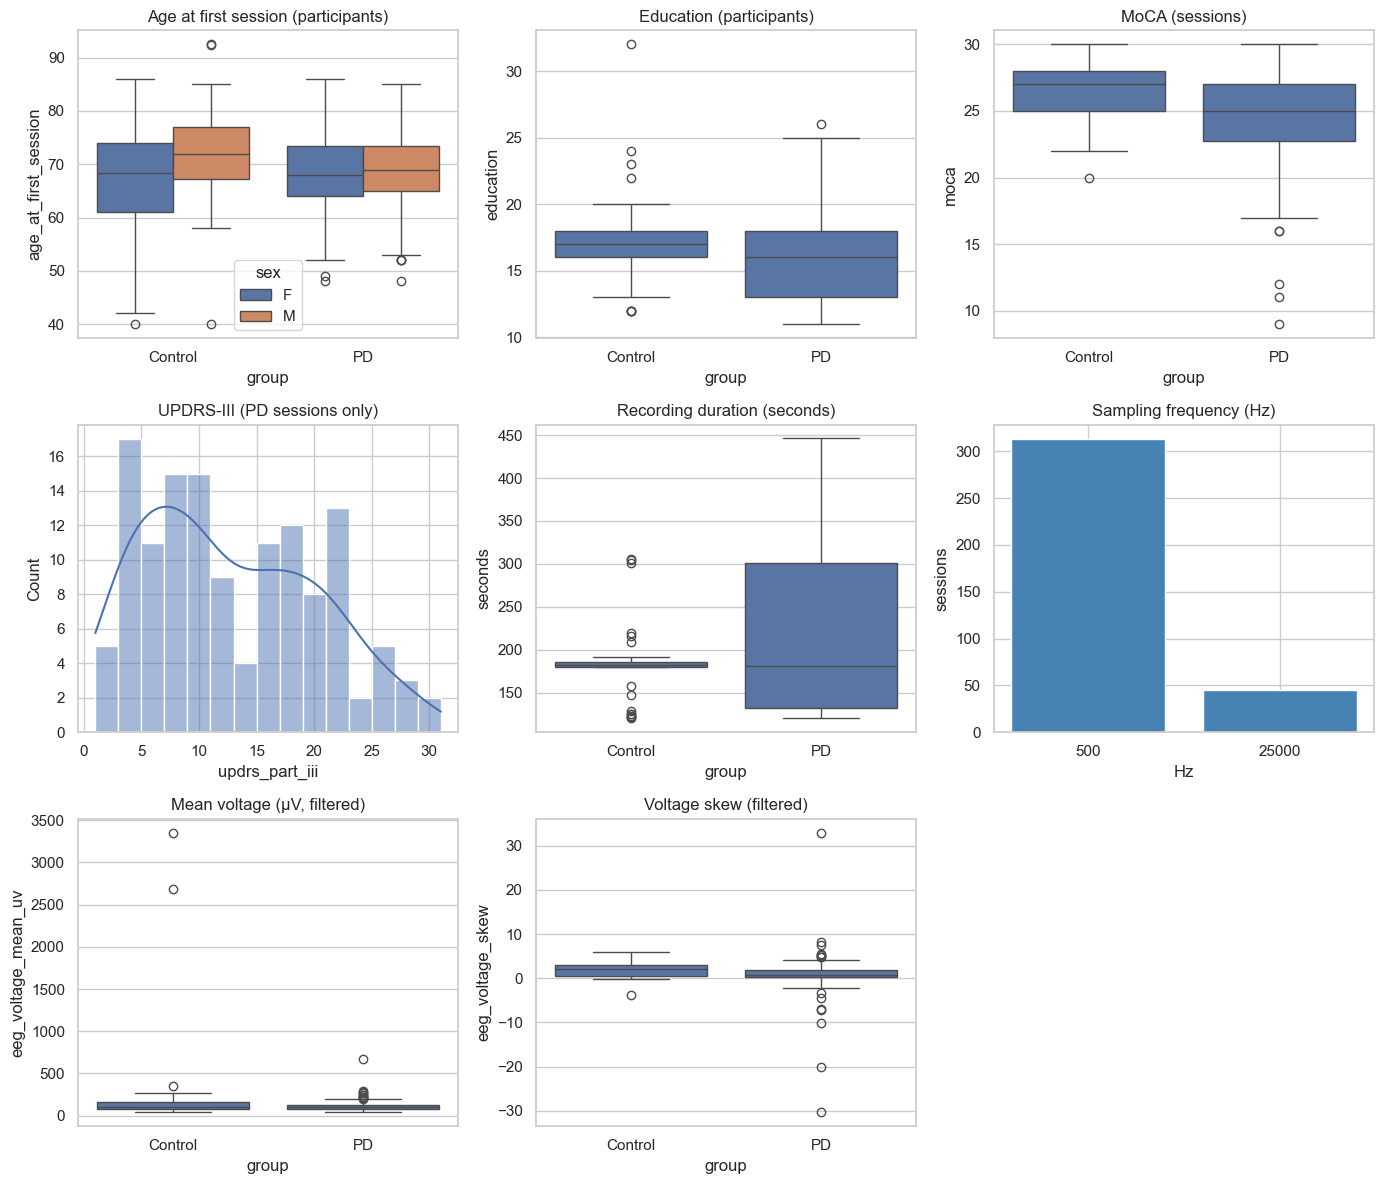

In [13]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "seaborn", "-q"])
    import matplotlib.pyplot as plt
    import seaborn as sns

sns.set_theme(style="whitegrid")

plot_df = modeling_table.copy()
plot_df["recording_duration_sec"] = pd.to_numeric(
    plot_df["recording_duration_sec"], errors="coerce"
)

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.ravel()

# 1) Age at first session
sns.boxplot(
    data=participant_index,
    x="group",
    y="age_at_first_session",
    hue="sex",
    ax=axes[0],
)
axes[0].set_title("Age at first session (participants)")

# 2) Education
sns.boxplot(data=participant_index, x="group", y="education", ax=axes[1])
axes[1].set_title("Education (participants)")

# 3) MoCA
sns.boxplot(data=modeling_table, x="group", y="moca", ax=axes[2])
axes[2].set_title("MoCA (sessions)")

# 4) UPDRS-III (PD only)
pd_sessions = modeling_table[modeling_table["group"] == "PD"]
sns.histplot(
    data=pd_sessions,
    x="updrs_part_iii",
    bins=15,
    kde=True,
    ax=axes[3],
)
axes[3].set_title("UPDRS-III (PD sessions only)")

# 5) Recording duration (only when EEG files were loaded)
if plot_df["recording_duration_sec"].notna().any():
    sns.boxplot(data=plot_df, x="group", y="recording_duration_sec", ax=axes[4])
    axes[4].set_title("Recording duration (seconds)")
    axes[4].set_ylabel("seconds")
else:
    axes[4].text(0.5, 0.5, "Duration unavailable\n(EEG not downloaded)", ha="center", va="center")
    axes[4].set_axis_off()

# 6) Sampling frequency
freq_counts = modeling_table["sampling_frequency_hz"].value_counts().sort_index()
axes[5].bar(freq_counts.index.astype(str), freq_counts.values, color="steelblue")
axes[5].set_title("Sampling frequency (Hz)")
axes[5].set_xlabel("Hz")
axes[5].set_ylabel("sessions")

# 7-9) Voltage summaries by group (local .eeg only)
voltage_plot_df = modeling_table.loc[
    modeling_table["voltage_available"].fillna(False)
].copy()
voltage_axes = [
    ("eeg_voltage_mean_uv", "Mean voltage (µV, filtered)"),
    ("eeg_voltage_skew", "Voltage skew (filtered)"),
]
for ax_idx, (col, title) in zip([6, 7], voltage_axes):
    voltage_plot_df[col] = pd.to_numeric(voltage_plot_df[col], errors="coerce")
    if voltage_plot_df[col].notna().any():
        sns.boxplot(data=voltage_plot_df, x="group", y=col, ax=axes[ax_idx])
        axes[ax_idx].set_title(title)
    else:
        axes[ax_idx].text(0.5, 0.5, "Voltage unavailable", ha="center", va="center")
        axes[ax_idx].set_title(title)

axes[8].set_visible(False)

plt.tight_layout()
plt.show()
